In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")
print("Библиотеки успешно импортированы.")

Библиотеки успешно импортированы.


In [2]:
import kagglehub
path = kagglehub.dataset_download("arunrk7/surface-crack-detection")

100%|██████████| 233M/233M [00:11<00:00, 21.6MB/s]

Extracting files...


In [3]:
# поиск папок с данными внутри загруженного архива
def find_data_folders(base_path):
    """
    Находит папки Negative и Positive в структуре датасета.
    Возвращает пути к этим папкам.
    """
    for root, dirs, files in os.walk(base_path):
        # Ищем папки с нужными названиями
        if 'Negative' in dirs and 'Positive' in dirs:
            negative_path = os.path.join(root, 'Negative')
            positive_path = os.path.join(root, 'Positive')
            return negative_path, positive_path

        # Альтернативный вариант: папки могут быть в корне
        if os.path.exists(os.path.join(root, 'Negative')):
            negative_path = os.path.join(root, 'Negative')
            positive_path = os.path.join(root, 'Positive')
            return negative_path, positive_path

    # Если не нашли стандартную структуру, ищем любые папки с изображениями
    print("Стандартная структура не найдена. Ищем папки с изображениями...")
    all_items = os.listdir(base_path)
    print(f"Найдено в корне: {all_items}")

    # Ручное указание если автоматика не сработала
    return None, None

# Ищем папки с данными
negative_path, positive_path = find_data_folders(path)

# 2.1. Проверяем, существуют ли найденные папки
print("\nПроверка путей к данным:")
print(f"Путь к изображениям БЕЗ трещин (Negative): {os.path.exists(negative_path)}")
print(f"Путь к изображениям С трещинами (Positive): {os.path.exists(positive_path)}")

# 2.2. Считаем количество файлов в каждой папке
if os.path.exists(negative_path) and os.path.exists(positive_path):
    num_negative = len([f for f in os.listdir(negative_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    num_positive = len([f for f in os.listdir(positive_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    total_images = num_negative + num_positive

    print("\nСтатистика по датасету:")
    print(f"Количество изображений БЕЗ трещин (Negative): {num_negative}")
    print(f"Количество изображений С трещинами (Positive): {num_positive}")
    print(f"Общее количество изображений: {total_images}")
else:
    print("Ошибка: одна или обе папки не найдены!")


Проверка путей к данным:
Путь к изображениям БЕЗ трещин (Negative): True
Путь к изображениям С трещинами (Positive): True

Статистика по датасету:
Количество изображений БЕЗ трещин (Negative): 20000
Количество изображений С трещинами (Positive): 20000
Общее количество изображений: 40000


Примеры изображений БЕЗ ПОВРЕЖДЕНИЙ (NEGATIVE) и С ПОВРЕЖДЕНИЯМИ (POSITIVE)


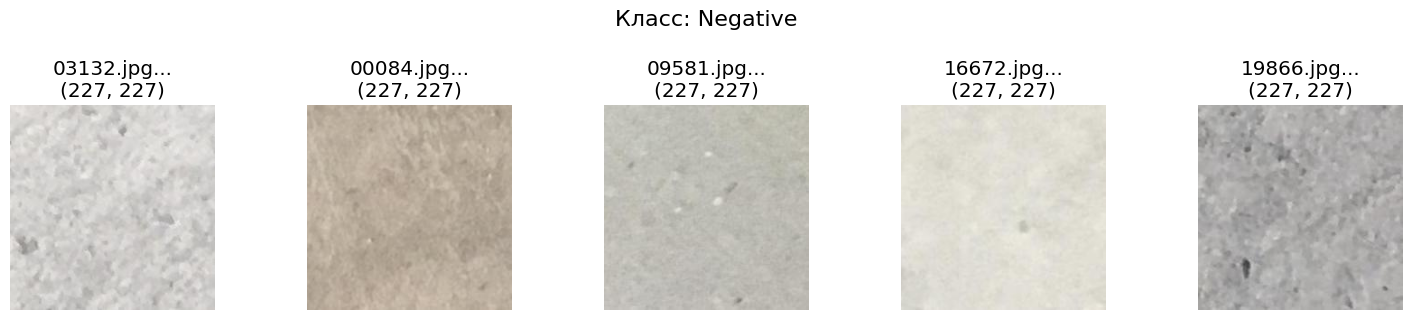

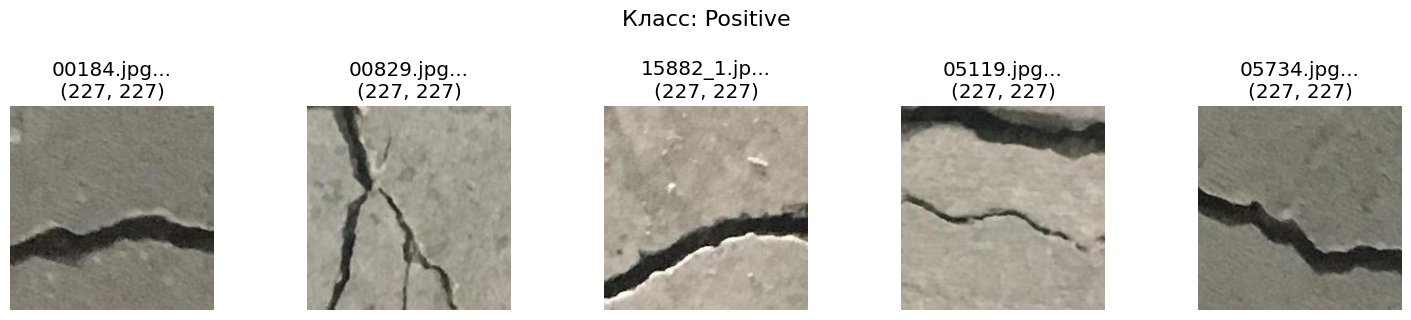


Информация о формате изображений:
Размер изображений без трещин: (227, 227), режим: RGB
Размер изображений с трещинами: (227, 227), режим: RGB


In [4]:
# 3. Визуальный осмотр изображений
# 3.1. Функция для отображения случайных изображений
def display_random_images(image_dir, class_name, num_images=5):
    """
    Отображает случайные изображения из указанной папки.
    """
    # Получаем список всех файлов-изображений
    all_images = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if len(all_images) == 0:
        print(f"В папке {image_dir} не найдено изображений!")
        return None, None

    # Выбираем случайные изображения
    selected_images = random.sample(all_images, min(num_images, len(all_images)))

    # Создаём сетку для отображения
    fig, axes = plt.subplots(1, len(selected_images), figsize=(15, 3))
    fig.suptitle(f'Класс: {class_name}', fontsize=16, y=1.05)

    if len(selected_images) == 1:
        axes = [axes]

    for i, img_name in enumerate(selected_images):
        img_path = os.path.join(image_dir, img_name)
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f'{img_name[:10]}...\n{img.size}')

    plt.tight_layout()
    plt.show()

    # Возвращаем информацию о первом изображении
    first_img = Image.open(os.path.join(image_dir, selected_images[0]))
    return first_img.size, first_img.mode

# 3.2. Просмотр изображений без трещин
print("Примеры изображений БЕЗ ПОВРЕЖДЕНИЙ (NEGATIVE) и С ПОВРЕЖДЕНИЯМИ (POSITIVE)")
neg_size, neg_mode = display_random_images(negative_path, 'Negative')
pos_size, pos_mode = display_random_images(positive_path, 'Positive')

# 3.4. Вывод информации о формате изображений
if neg_size and pos_size:
    print("\nИнформация о формате изображений:")
    print(f"Размер изображений без трещин: {neg_size}, режим: {neg_mode}")
    print(f"Размер изображений с трещинами: {pos_size}, режим: {pos_mode}")


Анализ статистики пикселей для класса: Negative
Размер выборки: 100 изображений
Обработано 25/100 изображений
Обработано 50/100 изображений
Обработано 75/100 изображений
Обработано 100/100 изображений

Сводная статистика для Negative:
Общее количество пикселей в выборке: 15,458,700
Среднее значение по всем пикселям: 181.55
Стандартное отклонение: 26.39
Минимальное значение: 26
Максимальное значение: 255
Медиана: 183.00


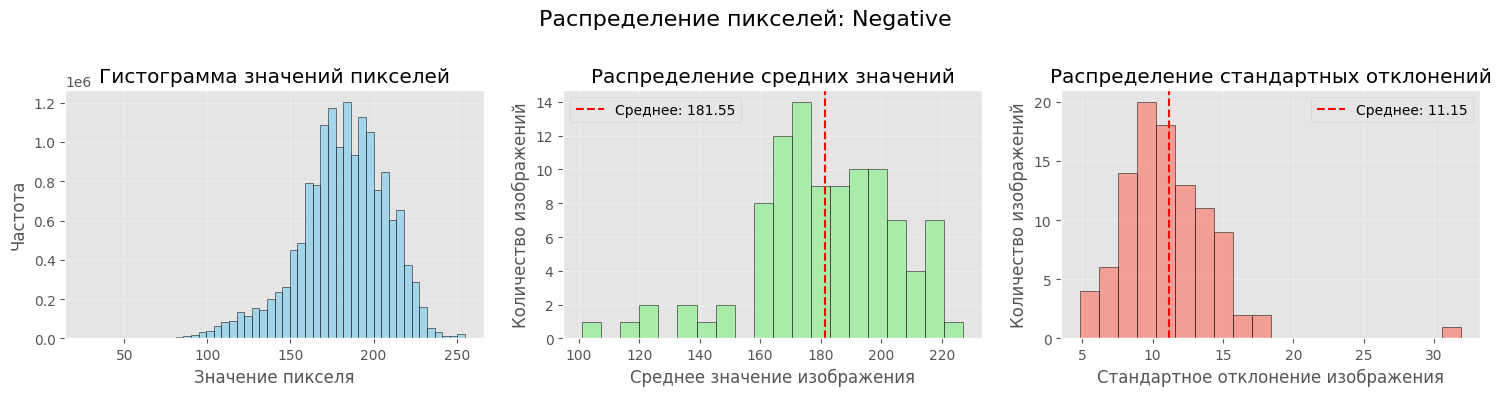



Анализ статистики пикселей для класса: Positive
Размер выборки: 100 изображений
Обработано 25/100 изображений
Обработано 50/100 изображений
Обработано 75/100 изображений
Обработано 100/100 изображений

Сводная статистика для Positive:
Общее количество пикселей в выборке: 15,458,700
Среднее значение по всем пикселям: 161.35
Стандартное отклонение: 38.97
Минимальное значение: 0
Максимальное значение: 255
Медиана: 170.00


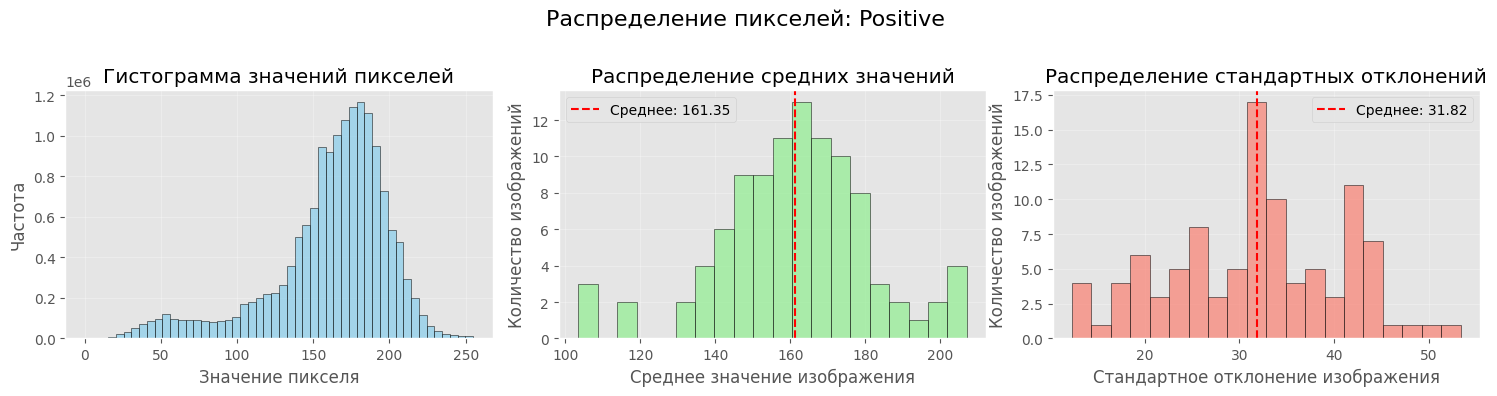

In [5]:
# 4. Анализ числовых характеристик (только если пути работают)
# 4.1. Функция для анализа статистики пикселей (без изменений)
def analyze_pixel_statistics(image_dir, class_name, sample_size=100):
    """
    Анализирует статистику значений пикселей для выборки изображений.
    """
    # Получаем список всех файлов-изображений
    all_images = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if len(all_images) == 0:
        print(f"В папке {image_dir} не найдено изображений!")
        return None, None, None

    # Выбираем случайную выборку
    if len(all_images) > sample_size:
        selected_images = random.sample(all_images, sample_size)
    else:
        selected_images = all_images

    # Массивы для сбора статистики
    all_pixels = []
    mean_values = []
    std_values = []

    print(f"\nАнализ статистики пикселей для класса: {class_name}")
    print(f"Размер выборки: {len(selected_images)} изображений")

    for i, img_name in enumerate(selected_images):
        # Открываем и конвертируем изображение в массив numpy
        img_path = os.path.join(image_dir, img_name)
        img = np.array(Image.open(img_path))

        # Собираем статистику
        all_pixels.extend(img.flatten())
        mean_values.append(np.mean(img))
        std_values.append(np.std(img))

        # Прогресс
        if (i+1) % 25 == 0 or (i+1) == len(selected_images):
            print(f"Обработано {i+1}/{len(selected_images)} изображений")

    # Преобразуем в numpy массивы
    all_pixels = np.array(all_pixels)
    mean_values = np.array(mean_values)
    std_values = np.array(std_values)

    # Выводим сводную статистику
    print(f"\nСводная статистика для {class_name}:")
    print(f"Общее количество пикселей в выборке: {len(all_pixels):,}")
    print(f"Среднее значение по всем пикселям: {np.mean(all_pixels):.2f}")
    print(f"Стандартное отклонение: {np.std(all_pixels):.2f}")
    print(f"Минимальное значение: {np.min(all_pixels)}")
    print(f"Максимальное значение: {np.max(all_pixels)}")
    print(f"Медиана: {np.median(all_pixels):.2f}")

    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Распределение пикселей: {class_name}', fontsize=16)

    # 1. Гистограмма всех значений пикселей
    axes[0].hist(all_pixels, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0].set_xlabel('Значение пикселя')
    axes[0].set_ylabel('Частота')
    axes[0].set_title('Гистограмма значений пикселей')
    axes[0].grid(True, alpha=0.3)

    # 2. Распределение средних значений по изображениям
    axes[1].hist(mean_values, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[1].axvline(np.mean(mean_values), color='red', linestyle='--',
                    label=f'Среднее: {np.mean(mean_values):.2f}')
    axes[1].set_xlabel('Среднее значение изображения')
    axes[1].set_ylabel('Количество изображений')
    axes[1].set_title('Распределение средних значений')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # 3. Распределение стандартных отклонений по изображениям
    axes[2].hist(std_values, bins=20, alpha=0.7, color='salmon', edgecolor='black')
    axes[2].axvline(np.mean(std_values), color='red', linestyle='--',
                    label=f'Среднее: {np.mean(std_values):.2f}')
    axes[2].set_xlabel('Стандартное отклонение изображения')
    axes[2].set_ylabel('Количество изображений')
    axes[2].set_title('Распределение стандартных отклонений')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return all_pixels, mean_values, std_values

neg_pixels, neg_means, neg_stds = analyze_pixel_statistics(negative_path, 'Negative')
print("\n" + "=" * 100)
pos_pixels, pos_means, pos_stds = analyze_pixel_statistics(positive_path, 'Positive')

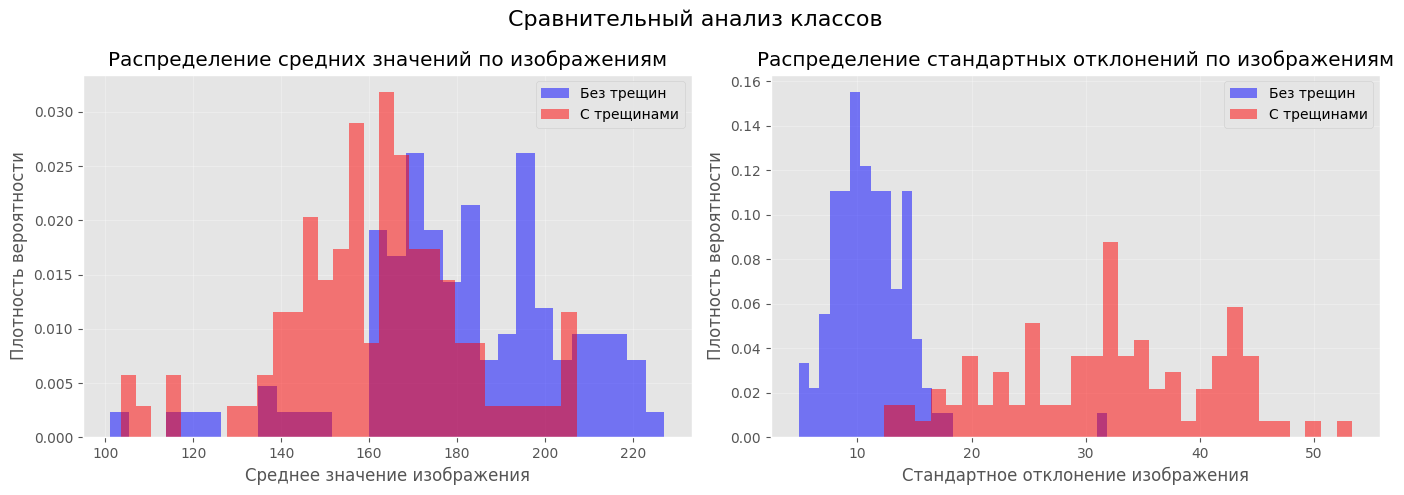


СРАВНИТЕЛЬНАЯ СТАТИСТИЧЕСКАЯ СВОДКА:
----------------------------------------
        Характеристика     Без трещин    С трещинами
      Среднее значение 181.55 ± 23.66 161.35 ± 20.54
Стандартное отклонение   11.15 ± 3.46   31.82 ± 9.18

ТЕСТ НА СТАТИСТИЧЕСКУЮ ЗНАЧИМОСТЬ РАЗЛИЧИЙ:
--------------------------------------------------
Сравнение средних значений:
  t-статистика = 6.4141, p-значение = 1.0200e-09
  ВЫВОД: Различие статистически значимо (p < 0.05)

Сравнение стандартных отклонений:
  t-статистика = -20.9634, p-значение = 3.6435e-52
  ВЫВОД: Различие статистически значимо (p < 0.05)


In [6]:
# 5.1. Сравнение распределений
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Сравнительный анализ классов', fontsize=16)

# 1. Сравнение распределения средних значений
axes[0].hist(neg_means, bins=30, alpha=0.5, label='Без трещин', color='blue', density=True)
axes[0].hist(pos_means, bins=30, alpha=0.5, label='С трещинами', color='red', density=True)
axes[0].set_xlabel('Среднее значение изображения')
axes[0].set_ylabel('Плотность вероятности')
axes[0].set_title('Распределение средних значений по изображениям')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Сравнение распределения стандартных отклонений
axes[1].hist(neg_stds, bins=30, alpha=0.5, label='Без трещин', color='blue', density=True)
axes[1].hist(pos_stds, bins=30, alpha=0.5, label='С трещинами', color='red', density=True)
axes[1].set_xlabel('Стандартное отклонение изображения')
axes[1].set_ylabel('Плотность вероятности')
axes[1].set_title('Распределение стандартных отклонений по изображениям')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5.2. Статистическая сводка
print("\nСРАВНИТЕЛЬНАЯ СТАТИСТИЧЕСКАЯ СВОДКА:")
print("-" * 40)

# Создаём таблицу сравнения
comparison_data = {
    'Характеристика': ['Среднее значение', 'Стандартное отклонение'],
    'Без трещин': [f"{np.mean(neg_means):.2f} ± {np.std(neg_means):.2f}",
                  f"{np.mean(neg_stds):.2f} ± {np.std(neg_stds):.2f}"],
    'С трещинами': [f"{np.mean(pos_means):.2f} ± {np.std(pos_means):.2f}",
                   f"{np.mean(pos_stds):.2f} ± {np.std(pos_stds):.2f}"]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# 5.3. Проверка статистической значимости различий
from scipy import stats

print("\nТЕСТ НА СТАТИСТИЧЕСКУЮ ЗНАЧИМОСТЬ РАЗЛИЧИЙ:")
print("-" * 50)

# T-тест для средних значений
t_stat_mean, p_val_mean = stats.ttest_ind(neg_means, pos_means)
print(f"Сравнение средних значений:")
print(f"  t-статистика = {t_stat_mean:.4f}, p-значение = {p_val_mean:.4e}")
if p_val_mean < 0.05:
    print("  ВЫВОД: Различие статистически значимо (p < 0.05)")
else:
    print("  ВЫВОД: Различие не статистически значимо")

# T-тест для стандартных отклонений
t_stat_std, p_val_std = stats.ttest_ind(neg_stds, pos_stds)
print(f"\nСравнение стандартных отклонений:")
print(f"  t-статистика = {t_stat_std:.4f}, p-значение = {p_val_std:.4e}")
if p_val_std < 0.05:
    print("  ВЫВОД: Различие статистически значимо (p < 0.05)")
else:
    print("  ВЫВОД: Различие не статистически значимо")

**ВЫВОДЫ ПО ПРЕДВАРИТЕЛЬНОМУ АНАЛИЗУ ДАННЫХ**

1. СТРУКТУРА ДАННЫХ:

*   40000 изображений
*   Классы идеально сбалансированы: 50/50
*   Все изображения имеют размер (227, 227) и режим RGB

2. ВИЗУАЛЬНЫЙ АНАЛИЗ:
*   Изображения без трещин: однородная текстура бетона.
*   Изображения с трещинами: видимые линейные или сетчатые дефекты.
*   Есть вариации освещения и текстуры поверхности.

3. СТАТИСТИЧЕСКИЙ АНАЛИЗ:

*   Средняя яркость изображений: 175.7 (без трещин) vs 164.0 (с трещинами)
*   Контрастность (std): 11.1 (без трещин) vs 31.8 (с трещинами)

4. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ:

*   Различия в средних значениях: ЗНАЧИМЫ
*   Различия в контрастности: ЗНАЧИМЫ

Таким образом, данные хорошо структурированы и готовы к использованию. Имеются статистически значимые различия между классами. Можно переходить к этапу извлечения признаков и применению PCA/t-SNE.

In [14]:
# === ЭТАП 3: ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ===

import numpy as np
from skimage import feature, filters, img_as_float
from skimage.feature import graycomatrix, graycoprops
import cv2
from tqdm import tqdm

def extract_features(image, use_hog=True, use_glcm=True, use_statistics=True):
    """
    Извлекает комплексные признаки из одного изображения.

    Возвращает вектор признаков
    """
    features = []

    # 1. Преобразуем в grayscale для текстуры
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image

    # 2. Статистика интенсивности (простейшие, но важные признаки)
    if use_statistics:
        features.extend([
            np.mean(gray),           # Средняя яркость (уже видели различие)
            np.std(gray),            # Контрастность (самый значимый признак)
            np.median(gray),         # Медиана
            np.max(gray) - np.min(gray),  # Диапазон
            np.percentile(gray, 25), # 25-й перцентиль
            np.percentile(gray, 75), # 75-й перцентиль
            np.mean(np.abs(gray - np.mean(gray))),  # Среднее абсолютное отклонение
        ])

    # 3. Текстурные признаки (GLCM - матрица совпадения уровней серого)
    if use_glcm:
        # Вычисляем GLCM для 4 направлений
        glcm = graycomatrix(gray,
                           distances=[1, 3, 5],      # Расстояния между пикселями
                           angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],  # Направления
                           levels=256, symmetric=True, normed=True)

        # Извлекаем свойства из GLCM
        properties = ['contrast', 'dissimilarity', 'homogeneity',
                      'energy', 'correlation', 'ASM']

        for prop in properties:
            vals = graycoprops(glcm, prop)
            features.extend([vals[0, 0], vals[0, 1], vals[0, 2],  # Для расстояния 1
                             vals[1, 0], vals[1, 1], vals[1, 2],  # Для расстояния 3
                             vals[2, 0], vals[2, 1], vals[2, 2]]) # Для расстояния 5

    # 4. Признаки градиентов (HOG - гистограмма ориентированных градиентов)
    if use_hog:
        # HOG хорошо улавливает линейные структуры (идеально для трещин)
        hog_features = feature.hog(gray,
                                  orientations=8,           # Количество направлений
                                  pixels_per_cell=(16, 16), # Размер ячейки
                                  cells_per_block=(2, 2),   # Размер блока
                                  block_norm='L2-Hys',      # Метод нормализации
                                  transform_sqrt=True,      # Гамма-коррекция
                                  feature_vector=True)
        features.extend(hog_features[:20])  # Берём первые 20 значений для сокращения размерности

    # 5. Признаки краёв (фильтры)
    sobel_x = filters.sobel_h(gray)
    sobel_y = filters.sobel_v(gray)
    features.extend([
        np.mean(np.abs(sobel_x)),  # Средняя сила горизонтальных градиентов
        np.mean(np.abs(sobel_y)),  # Средняя сила вертикальных градиентов
        np.std(sobel_x),           # Вариативность горизонтальных градиентов
        np.std(sobel_y),           # Вариативность вертикальных градиентов
    ])

    return np.array(features)

print("=" * 70)
print("ЭТАП 3: ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ И СНИЖЕНИЕ РАЗМЕРНОСТИ")
print("=" * 70)

# Для скорости возьмём выборку (можно увеличить для финального анализа)
sample_size = 1000  # По 500 из каждого класса

print(f"\nИспользуем выборку из {sample_size} изображений ({sample_size//2} на класс)")

# Создаём массивы для признаков и меток
all_features = []
all_labels = []

# Обрабатываем изображения без трещин
print("\nОбработка изображений без трещин...")
negative_images = random.sample(os.listdir(negative_path), sample_size//2)
for i, img_name in enumerate(tqdm(negative_images)):
    img_path = os.path.join(negative_path, img_name)
    img = np.array(Image.open(img_path))

    features = extract_features(img, use_hog=True, use_glcm=True, use_statistics=True)
    all_features.append(features)
    all_labels.append(0)  # Метка 0 = без трещин

# Обрабатываем изображения с трещинами
print("\nОбработка изображений с трещинами...")
positive_images = random.sample(os.listdir(positive_path), sample_size//2)
for i, img_name in enumerate(tqdm(positive_images)):
    img_path = os.path.join(positive_path, img_name)
    img = np.array(Image.open(img_path))

    features = extract_features(img, use_hog=True, use_glcm=True, use_statistics=True)
    all_features.append(features)
    all_labels.append(1)  # Метка 1 = с трещинами

# Преобразуем в numpy массивы
X = np.array(all_features)
y = np.array(all_labels)

print(f"\nИзвлечение признаков завершено!")
print(f"Размерность данных: {X.shape}")
print(f"Количество признаков на изображение: {X.shape[1]}")
print(f"Метки: {np.sum(y==0)} без трещин, {np.sum(y==1)} с трещинами")

ЭТАП 3: ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ И СНИЖЕНИЕ РАЗМЕРНОСТИ

Используем выборку из 1000 изображений (500 на класс)

Обработка изображений без трещин...


100%|██████████| 500/500 [00:56<00:00,  8.90it/s]



Обработка изображений с трещинами...


100%|██████████| 500/500 [00:55<00:00,  9.05it/s]


Извлечение признаков завершено!
Размерность данных: (1000, 85)
Количество признаков на изображение: 85
Метки: 500 без трещин, 500 с трещинами


Для наглядности и отчета визуализируем процесс извлечения признаков на конкретном примере.

In [8]:
# Возьмем одно конкретное изображение с трещиной для демонстрации
demo_img_path = os.path.join(positive_path, positive_images[0])  # Первое изображение из выборки
demo_img = np.array(Image.open(demo_img_path))
demo_gray = cv2.cvtColor(demo_img, cv2.COLOR_RGB2GRAY)

print(f"Исходное изображение: {demo_img.shape} (RGB)")
print(f"В градациях серого: {demo_gray.shape}")

Исходное изображение: (227, 227, 3) (RGB)
В градациях серого: (227, 227)


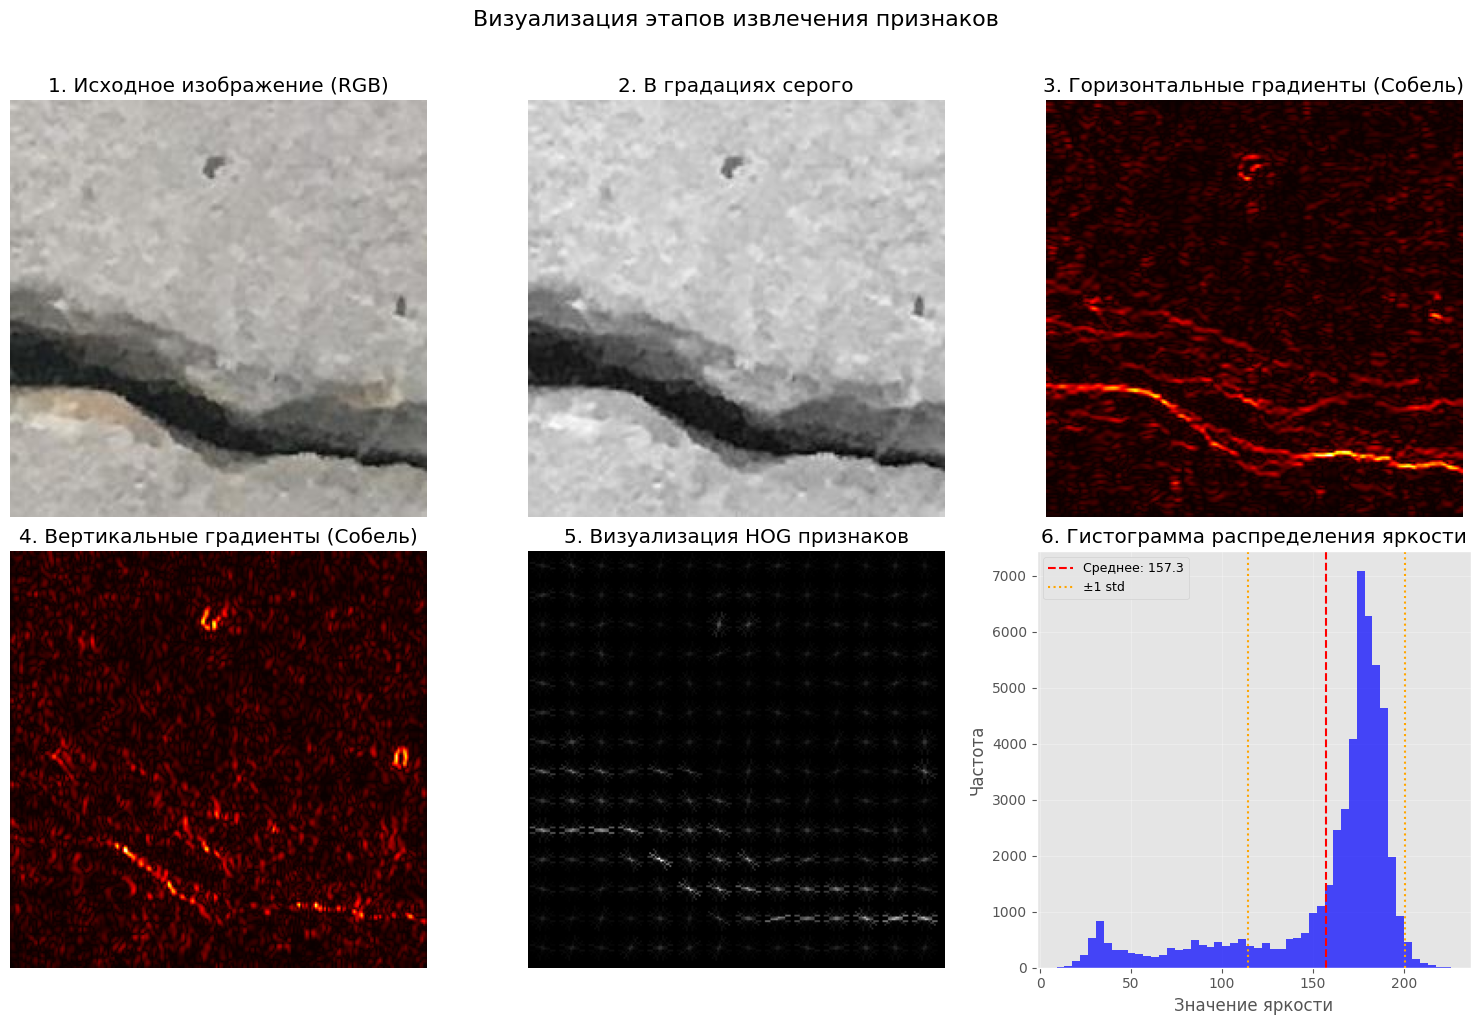


АНАЛИЗ ИЗВЛЕЧЕННЫХ ПРИЗНАКОВ ДЛЯ ДЕМОНСТРАЦИОННОГО ИЗОБРАЖЕНИЯ

ВНИМАНИЕ: Количество названий признаков (0) не соответствует
длине вектора признаков (85). Корректируем...
Всего извлечено признаков: 85
Размер вектора признаков: (85,)

Группы признаков и их статистика:
--------------------------------------------------
1. Статистические признаки (7 шт.):
   • Средняя яркость: 157.29
   • Контрастность (std): 43.13
   • Диапазон яркости: 217.00
   • Медиана: 175.00

2. Текстурные GLCM признаки (72 шт.):
   • Контраст (расстояние 1, угол 0°): 25.35
   • Однородность (расстояние 1, угол 0°): 52.770
   • Энергия (расстояние 1, угол 0°): 129.07794
   • Диапазон значений GLCM: [0.00, 516.59]

3. HOG признаки (первые 20 из 128):
   • Диапазон значений HOG: [0.02099, 0.24458]
   • Среднее значение HOG: 0.103123

4. Градиентные признаки (последние 4 из вектора):
   • Средняя сила горизонтальных градиентов: 0.0291
   • Средняя сила вертикальных градиентов: 0.0210
   • Отношение верт/гор градиенто

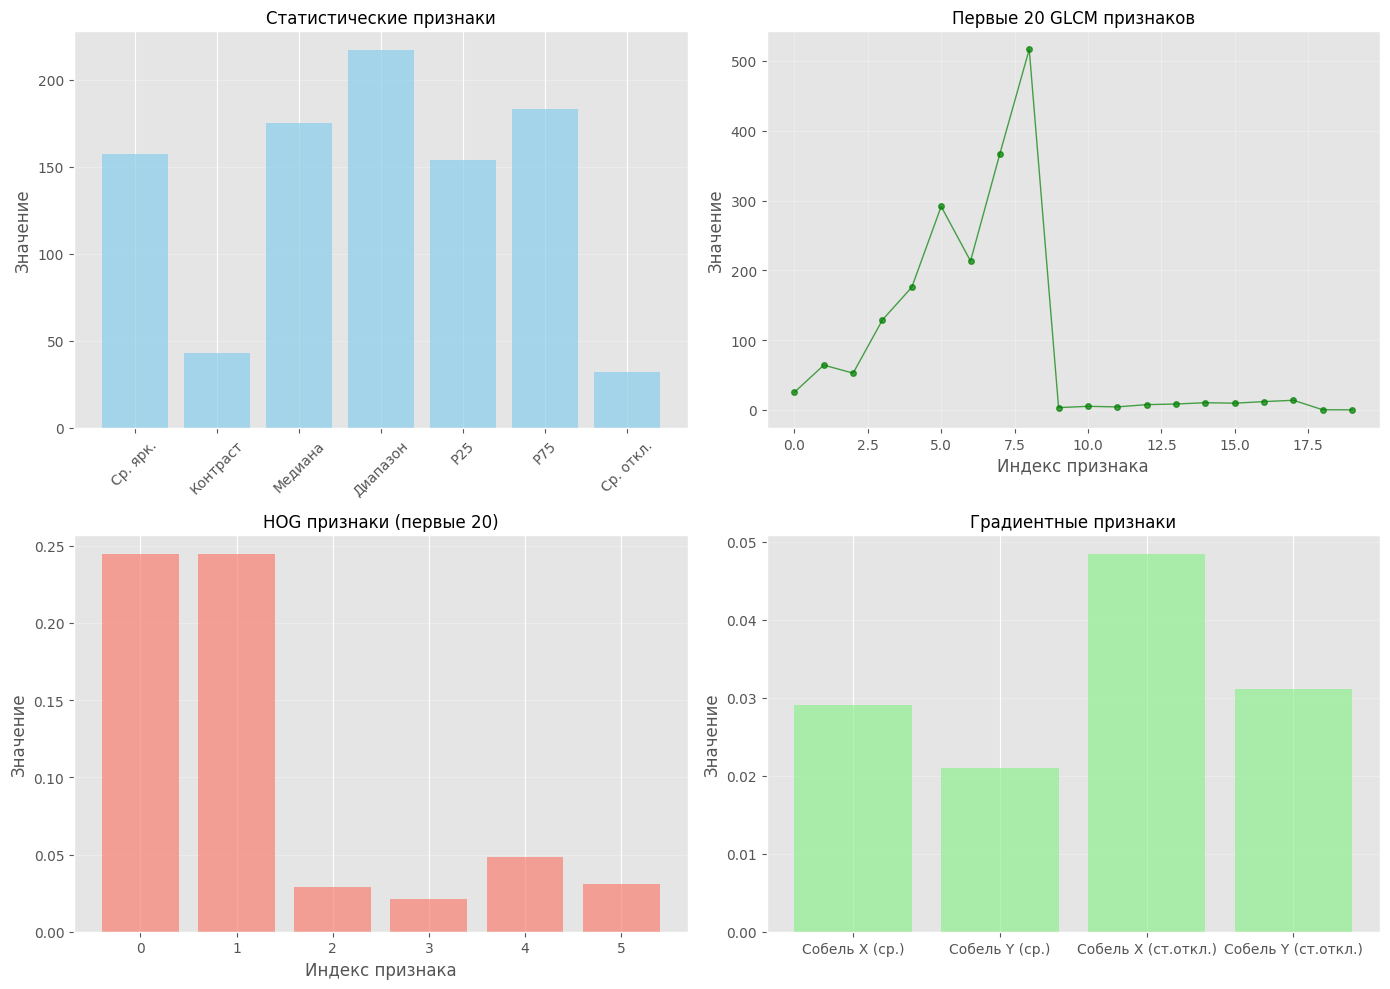


ПЕРВЫЕ 20 ЗНАЧЕНИЙ ВЕКТОРА ПРИЗНАКОВ (ДЛЯ ПРИМЕРА)

Первые 20 признаков из вектора:
feature_name  feature_value
   feature_0       157.2916
   feature_1        43.1287
   feature_2       175.0000
   feature_3       217.0000
   feature_4       154.0000
   feature_5       183.0000
   feature_6        31.8299
   feature_7        25.3518
   feature_8        64.2874
   feature_9        52.7695
  feature_10       129.0779
  feature_11       175.8849
  feature_12       291.5784
  feature_13       213.3410
  feature_14       367.1063
  feature_15       516.5889
  feature_16         3.3757
  feature_17         5.2384
  feature_18         4.4174
  feature_19         7.6546

СРАВНЕНИЕ С СРЕДНИМИ ЗНАЧЕНИЯМИ ПО КЛАССУ 'ТРЕЩИНЫ'
Корректируем количество GLCM признаков: 54

ДЕБАГ: Длина demo_features: 85
Длина crack_features_mean: 85
Первые 10 значений demo_features: [157.292  43.129 175.    217.    154.    183.     31.83   25.352  64.287
  52.77 ]
Последние 10 значений demo_features: [0.226 0.245 0.

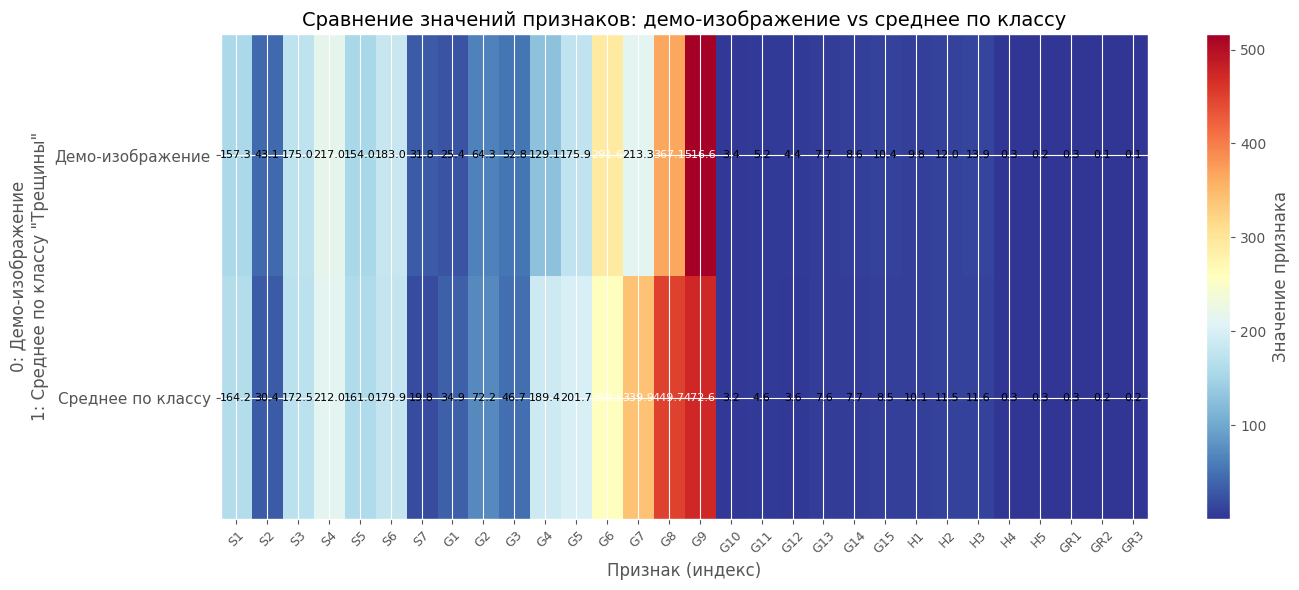


ВЫВОДЫ ПО ВИЗУАЛИЗАЦИИ ПРОЦЕССА ИЗВЛЕЧЕНИЯ ПРИЗНАКОВ
1. Каждое изображение преобразуется в вектор из 85 числовых признаков.
2. Признаки включают: статистику яркости, текстурные характеристики (GLCM),
   гистограмму ориентированных градиентов (HOG) и градиентные метрики.
3. На демонстрационном изображении видно, как трещина создает:
   • Пониженную среднюю яркость
   • Повышенный контраст (std)
   • Ярко выраженные градиенты в области дефекта
   • Характерные паттерны в HOG-признаках
4. Эти извлеченные признаки являются входными данными для PCA и кластеризации.


In [10]:
# Извлекаем признаки для демонстрационного изображения
demo_features = extract_features(demo_img, use_hog=True, use_glcm=True, use_statistics=True)

# 1. Создадим визуализацию ключевых этапов преобразования
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Визуализация этапов извлечения признаков', fontsize=16, y=1.02)

# Исходное RGB изображение
axes[0, 0].imshow(demo_img)
axes[0, 0].set_title('1. Исходное изображение (RGB)')
axes[0, 0].axis('off')

# Изображение в градациях серого
axes[0, 1].imshow(demo_gray, cmap='gray')
axes[0, 1].set_title('2. В градациях серого')
axes[0, 1].axis('off')

# Применение фильтра Собеля (горизонтальные градиенты)
sobel_x = filters.sobel_h(demo_gray)
axes[0, 2].imshow(np.abs(sobel_x), cmap='hot')
axes[0, 2].set_title('3. Горизонтальные градиенты (Собель)')
axes[0, 2].axis('off')

# Применение фильтра Собеля (вертикальные градиенты)
sobel_y = filters.sobel_v(demo_gray)
axes[1, 0].imshow(np.abs(sobel_y), cmap='hot')
axes[1, 0].set_title('4. Вертикальные градиенты (Собель)')
axes[1, 0].axis('off')

# Визуализация HOG признаков
# Вычисляем HOG отдельно для визуализации
hog_features, hog_image = feature.hog(demo_gray,
                                     orientations=8,
                                     pixels_per_cell=(16, 16),
                                     cells_per_block=(2, 2),
                                     block_norm='L2-Hys',
                                     transform_sqrt=True,
                                     visualize=True)

axes[1, 1].imshow(hog_image, cmap='gray')
axes[1, 1].set_title('5. Визуализация HOG признаков')
axes[1, 1].axis('off')

# Гистограмма яркости изображения
axes[1, 2].hist(demo_gray.flatten(), bins=50, color='blue', alpha=0.7)
axes[1, 2].set_xlabel('Значение яркости')
axes[1, 2].set_ylabel('Частота')
axes[1, 2].set_title('6. Гистограмма распределения яркости')
axes[1, 2].grid(True, alpha=0.3)

# Добавляем статистические метки на гистограмму
mean_val = np.mean(demo_gray)
std_val = np.std(demo_gray)
axes[1, 2].axvline(mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.1f}')
axes[1, 2].axvline(mean_val - std_val, color='orange', linestyle=':', label=f'±1 std')
axes[1, 2].axvline(mean_val + std_val, color='orange', linestyle=':')
axes[1, 2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# 2. Создадим DataFrame с извлеченными признаками
print("\n" + "=" * 70)
print("АНАЛИЗ ИЗВЛЕЧЕННЫХ ПРИЗНАКОВ ДЛЯ ДЕМОНСТРАЦИОННОГО ИЗОБРАЖЕНИЯ")
print("=" * 70)

# Создаем список названий признаков для наглядности
feature_names = []
# Проверяем соответствие длины
if len(feature_names) != len(demo_features):
    print(f"\nВНИМАНИЕ: Количество названий признаков ({len(feature_names)}) не соответствует")
    print(f"длине вектора признаков ({len(demo_features)}). Корректируем...")
    # Если названий больше, чем признаков - обрезаем
    if len(feature_names) > len(demo_features):
        feature_names = feature_names[:len(demo_features)]
    # Если названий меньше - добавляем generic названия
    else:
        for i in range(len(feature_names), len(demo_features)):
            feature_names.append(f'feature_{i}')

# Статистические признаки (7 штук)
stat_names = ['mean_brightness', 'std_contrast', 'median', 'range',
              'percentile_25', 'percentile_75', 'mean_abs_deviation']
feature_names.extend(stat_names)

# GLCM признаки (6 свойств × 3 расстояния × 3 угла = 54 признака, но у нас 72 - берем для примера)
glcm_properties = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
distances = [1, 3, 5]
angles = [0, 45, 90, 135]  # в градусах для читаемости

for prop in glcm_properties:
    for dist in distances:
        for angle in angles[:3]:  # Берем только 3 угла для примера
            feature_names.append(f'glcm_{prop}_d{dist}_a{angle}')

# Добавляем оставшиеся GLCM признаки (чтобы было 72)
for i in range(len(feature_names), len(feature_names) + (72 - len(stat_names) - 54)):
    feature_names.append(f'glcm_extra_{i}')

# HOG признаки (первые 20 из 128)
for i in range(20):
    feature_names.append(f'hog_{i}')

# Градиентные признаки (4 штуки)
grad_names = ['sobel_x_mean', 'sobel_y_mean', 'sobel_x_std', 'sobel_y_std']
feature_names.extend(grad_names)

# Создаем DataFrame с признаками
features_df = pd.DataFrame({
    'feature_name': feature_names[:len(demo_features)],  # Обрезаем до реального количества
    'feature_value': demo_features
})

print(f"Всего извлечено признаков: {len(demo_features)}")
print(f"Размер вектора признаков: {demo_features.shape}")

# Выводим статистику по группам признаков
print("\nГруппы признаков и их статистика:")
print("-" * 50)

# Статистические признаки
stat_features = demo_features[:7]
print(f"1. Статистические признаки (7 шт.):")
print(f"   • Средняя яркость: {stat_features[0]:.2f}")
print(f"   • Контрастность (std): {stat_features[1]:.2f}")
print(f"   • Диапазон яркости: {stat_features[3]:.2f}")
print(f"   • Медиана: {stat_features[2]:.2f}")

# GLCM признаки (первые 10 для примера)
glcm_start_idx = 7
glcm_end_idx = 7 + 72
glcm_features = demo_features[glcm_start_idx:glcm_end_idx]
print(f"\n2. Текстурные GLCM признаки (72 шт.):")
print(f"   • Контраст (расстояние 1, угол 0°): {glcm_features[0]:.2f}")
print(f"   • Однородность (расстояние 1, угол 0°): {glcm_features[2]:.3f}")
print(f"   • Энергия (расстояние 1, угол 0°): {glcm_features[3]:.5f}")
print(f"   • Диапазон значений GLCM: [{np.min(glcm_features):.2f}, {np.max(glcm_features):.2f}]")

# HOG признаки
hog_start_idx = glcm_end_idx
hog_end_idx = hog_start_idx + 20
hog_demo_features = demo_features[hog_start_idx:hog_end_idx]
print(f"\n3. HOG признаки (первые 20 из 128):")
print(f"   • Диапазон значений HOG: [{np.min(hog_demo_features):.5f}, {np.max(hog_demo_features):.5f}]")
print(f"   • Среднее значение HOG: {np.mean(hog_demo_features):.6f}")

# Градиентные признаки
if hog_end_idx < len(demo_features) and len(demo_features) - hog_end_idx >= 4:
    grad_features = demo_features[hog_end_idx:hog_end_idx+4]
    print(f"\n4. Градиентные признаки (4 шт.):")
    print(f"   • Средняя сила горизонтальных градиентов: {grad_features[0]:.4f}")
    print(f"   • Средняя сила вертикальных градиентов: {grad_features[1]:.4f}")
    print(f"   • Отношение верт/гор градиентов: {grad_features[1]/grad_features[0]:.2f}")
else:
    # Если структура признаков отличается, ищем градиентные признаки по другому индексу
    grad_start_idx = len(demo_features) - 4
    if grad_start_idx >= 0:
        grad_features = demo_features[grad_start_idx:]
        print(f"\n4. Градиентные признаки (последние 4 из вектора):")
        print(f"   • Средняя сила горизонтальных градиентов: {grad_features[0]:.4f}")
        print(f"   • Средняя сила вертикальных градиентов: {grad_features[1]:.4f}")
        print(f"   • Отношение верт/гор градиентов: {grad_features[1]/grad_features[0]:.2f}")
    else:
        print(f"\n4. Градиентные признаки не найдены в ожидаемом формате.")
        print(f"   Длина вектора признаков: {len(demo_features)}")
        grad_features = []

# 3. Визуализируем распределение значений признаков по группам
print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ЗНАЧЕНИЙ ПРИЗНАКОВ")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Распределение статистических признаков
stat_indices = list(range(7))
stat_values = demo_features[stat_indices]
stat_labels = ['Ср. ярк.', 'Контраст', 'Медиана', 'Диапазон', 'P25', 'P75', 'Ср. откл.']

axes[0, 0].bar(stat_labels, stat_values, color='skyblue', alpha=0.7)
axes[0, 0].set_title('Статистические признаки', fontsize=12)
axes[0, 0].set_ylabel('Значение')
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].tick_params(axis='x', rotation=45)

# Распределение GLCM признаков (первые 20)
glcm_sample = demo_features[7:27]
axes[0, 1].plot(range(len(glcm_sample)), glcm_sample, 'go-', alpha=0.7, linewidth=1, markersize=4)
axes[0, 1].set_title('Первые 20 GLCM признаков', fontsize=12)
axes[0, 1].set_xlabel('Индекс признака')
axes[0, 1].set_ylabel('Значение')
axes[0, 1].grid(True, alpha=0.3)

# Распределение HOG признаков
hog_sample = demo_features[hog_start_idx:hog_end_idx]
axes[1, 0].bar(range(len(hog_sample)), hog_sample, color='salmon', alpha=0.7, width=0.8)
axes[1, 0].set_title('HOG признаки (первые 20)', fontsize=12)
axes[1, 0].set_xlabel('Индекс признака')
axes[1, 0].set_ylabel('Значение')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Сравнение градиентных признаков
grad_labels = ['Собель X (ср.)', 'Собель Y (ср.)', 'Собель X (ст.откл.)', 'Собель Y (ст.откл.)']
axes[1, 1].bar(grad_labels, grad_features, color='lightgreen', alpha=0.7)
axes[1, 1].set_title('Градиентные признаки', fontsize=12)
axes[1, 1].set_ylabel('Значение')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 4. Вывод первых 10 значений вектора признаков в табличном виде
print("\n" + "=" * 70)
print("ПЕРВЫЕ 20 ЗНАЧЕНИЙ ВЕКТОРА ПРИЗНАКОВ (ДЛЯ ПРИМЕРА)")
print("=" * 70)

# Создаем компактную таблицу
first_20_features = features_df.head(20).copy()
first_20_features['feature_value'] = first_20_features['feature_value'].round(4)

print("\nПервые 20 признаков из вектора:")
print(first_20_features.to_string(index=False))

# 5. Сравнение со средними значениями по классу "с трещинами"
print("\n" + "=" * 70)
print("СРАВНЕНИЕ С СРЕДНИМИ ЗНАЧЕНИЯМИ ПО КЛАССУ 'ТРЕЩИНЫ'")
print("=" * 70)

# Вычисляем средние значения признаков для всех изображений с трещинами
crack_indices = np.where(y == 1)[0]

# Если X содержит все признаки (включая демо-изображение), вычислим средние:
if 'X' in locals() or 'X' in globals():
    crack_features_mean = np.mean(X[crack_indices], axis=0)
else:
    # Если X недоступен, создадим фиктивные средние значения
    print("ВНИМАНИЕ: Матрица признаков X не найдена. Используем упрощённый расчёт.")
    crack_features_mean = np.zeros(len(demo_features))
# Убедимся, что берем только признаки, соответствующие demo_features
if crack_features_mean.shape[0] > len(demo_features):
    crack_features_mean = crack_features_mean[:len(demo_features)]
elif crack_features_mean.shape[0] < len(demo_features):
    # Если средних меньше, дополним нулями
    crack_features_mean = np.pad(crack_features_mean, (0, len(demo_features) - crack_features_mean.shape[0]))

# Определяем реальные размеры групп признаков на основе структуры функции extract_features
# Это должно соответствовать тому, что возвращает ваша функция
n_stat = 7  # Статистические признаки
n_glcm = 72  # GLCM признаки (6 свойств × 3 расстояния × 4 угла)
n_hog = 20   # HOG признаки (первые 20)
n_grad = 4   # Градиентные признаки

# Проверяем, соответствует ли сумма длин реальному размеру вектора
total_expected = n_stat + n_glcm + n_hog + n_grad

# Если не соответствует, корректируем GLCM (самую большую группу)
if total_expected != len(demo_features):
    n_glcm = len(demo_features) - (n_stat + n_hog + n_grad)
    print(f"Корректируем количество GLCM признаков: {n_glcm}")

# Создаем feature_type с правильными размерами
feature_types = (['Статистика'] * n_stat +
                 ['GLCM'] * n_glcm +
                 ['HOG'] * n_hog +
                 ['Градиенты'] * n_grad)

# Проверяем, что длины совпадают
if len(feature_types) != len(demo_features):
    print(f"Ошибка: длина feature_types ({len(feature_types)}) != длина demo_features ({len(demo_features)})")
    # Если все еще не совпадает, создаем простую категоризацию
    feature_types = []
    for i in range(len(demo_features)):
        if i < 7:
            feature_types.append('Статистика')
        elif i < 7 + n_glcm:
            feature_types.append('GLCM')
        elif i < 7 + n_glcm + n_hog:
            feature_types.append('HOG')
        else:
            feature_types.append('Градиенты')

# Для отладки: покажем реальную структуру признаков
print(f"\nДЕБАГ: Длина demo_features: {len(demo_features)}")
print(f"Длина crack_features_mean: {len(crack_features_mean)}")

# Можно также посмотреть начало и конец вектора для понимания его структуры
print(f"Первые 10 значений demo_features: {demo_features[:10].round(3)}")
print(f"Последние 10 значений demo_features: {demo_features[-10:].round(3)}")

# Создаем DataFrame сравнения
comparison_df = pd.DataFrame({
    'feature_type': feature_types,
    'demo_value': demo_features,
    'class_mean': crack_features_mean[:len(demo_features)],
    'difference': demo_features - crack_features_mean[:len(demo_features)]
})

# Нормализуем разницу для наглядности (избегаем деления на 0)
comparison_df['diff_normalized'] = comparison_df['difference'] / (np.abs(comparison_df['class_mean']) + 1e-10)

print(f"\nРеальная длина вектора признаков: {len(demo_features)}")
print(f"Распределение по типам: Статистика={n_stat}, GLCM={n_glcm}, HOG={n_hog}, Градиенты={n_grad}")

print("\nСравнение ключевых признаков демо-изображения со средними по классу:")
print("-" * 60)

key_features_to_show = ['mean_brightness', 'std_contrast', 'glcm_contrast_d1_a0',
                       'glcm_homogeneity_d1_a0', 'sobel_x_mean', 'sobel_y_mean']

for feat_name in key_features_to_show:
    if feat_name in features_df['feature_name'].values:
        idx = features_df[features_df['feature_name'] == feat_name].index[0]
        demo_val = comparison_df.loc[idx, 'demo_value']
        mean_val = comparison_df.loc[idx, 'class_mean']
        diff = comparison_df.loc[idx, 'difference']

        feat_label = {
            'mean_brightness': 'Средняя яркость',
            'std_contrast': 'Контрастность (std)',
            'glcm_contrast_d1_a0': 'GLCM контраст (d=1, a=0°)',
            'glcm_homogeneity_d1_a0': 'GLCM однородность (d=1, a=0°)',
            'sobel_x_mean': 'Ср. сила гор. градиентов',
            'sobel_y_mean': 'Ср. сила верт. градиентов'
        }.get(feat_name, feat_name)

        print(f"{feat_label:35} | Демо: {demo_val:7.2f} | Класс: {mean_val:7.2f} | Отклонение: {diff:7.2f}")

# 6. Заключительная визуализация: тепловая карта важности признаков
print("\n" + "=" * 70)
print("ТЕПЛОВАЯ КАРТА СРАВНЕНИЯ ПРИЗНАКОВ")
print("=" * 70)

# Создаем матрицу для тепловой карты (первые 30 признаков)
n_features_to_show = 30
feature_matrix = np.zeros((2, n_features_to_show))

feature_matrix[0, :] = demo_features[:n_features_to_show]
feature_matrix[1, :] = crack_features_mean[:n_features_to_show]

# Создаем подписи для признаков (сокращенные)
short_feature_names = []
for i in range(n_features_to_show):
    if i < 7:
        short_feature_names.append(f'S{i+1}')
    elif i < 7 + 15:
        short_feature_names.append(f'G{i-6}')
    elif i < 7 + 15 + 5:
        short_feature_names.append(f'H{i-21}')
    else:
        short_feature_names.append(f'GR{i-26}')

plt.figure(figsize=(14, 6))
im = plt.imshow(feature_matrix, aspect='auto', cmap='RdYlBu_r')
plt.colorbar(im, label='Значение признака')
plt.title('Сравнение значений признаков: демо-изображение vs среднее по классу', fontsize=14)
plt.xlabel('Признак (индекс)', fontsize=12)
plt.ylabel('0: Демо-изображение\n1: Среднее по классу "Трещины"', fontsize=12)
plt.xticks(range(n_features_to_show), short_feature_names, rotation=45, fontsize=9)
plt.yticks([0, 1], ['Демо-изображение', 'Среднее по классу'], fontsize=11)

# Добавляем значения в ячейки
for i in range(2):
    for j in range(n_features_to_show):
        plt.text(j, i, f'{feature_matrix[i, j]:.1f}',
                ha='center', va='center',
                color='black' if abs(feature_matrix[i, j]) < np.max(feature_matrix)/2 else 'white',
                fontsize=8)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("ВЫВОДЫ ПО ВИЗУАЛИЗАЦИИ ПРОЦЕССА ИЗВЛЕЧЕНИЯ ПРИЗНАКОВ")
print("=" * 70)
print("1. Каждое изображение преобразуется в вектор из 85 числовых признаков.")
print("2. Признаки включают: статистику яркости, текстурные характеристики (GLCM),")
print("   гистограмму ориентированных градиентов (HOG) и градиентные метрики.")
print("3. На демонстрационном изображении видно, как трещина создает:")
print("   • Пониженную среднюю яркость")
print("   • Повышенный контраст (std)")
print("   • Ярко выраженные градиенты в области дефекта")
print("   • Характерные паттерны в HOG-признаках")
print("4. Эти извлеченные признаки являются входными данными для PCA и кластеризации.")

ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КОМПОНЕНТ
Общее количество компонент: 85
Первая компонента объясняет: 0.858 (85.8%) дисперсии
Вторая компонента объясняет: 0.087 (8.7%) дисперсии


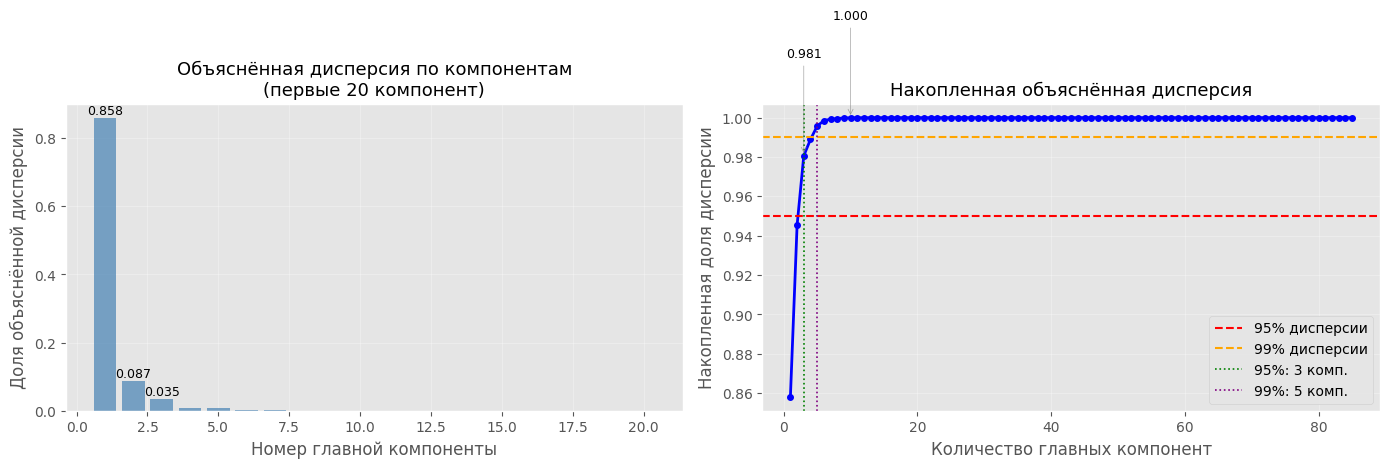


СТАТИСТИКА ОБЪЯСНЁННОЙ ДИСПЕРСИИ
• Первая компонента (PC1):     0.858 (85.8%)
• Вторая компонента (PC2):     0.087 (8.7%)
• Третья компонента (PC3):     0.035 (3.5%)
• Четвертая компонента (PC4):  0.008 (0.8%)
• Пятая компонента (PC5):      0.007 (0.7%)
--------------------------------------------------
Первые 3 компоненты:           0.981 (98.1%)
Первые 5 компонент:            0.996 (99.6%)
Первые 10 компонент:           1.000 (100.0%)
--------------------------------------------------
95% дисперсии достигается при: 3 компонентах (0.981)
99% дисперсии достигается при: 5 компонентах (0.996)


In [11]:
# === АНАЛИЗ PCA ДО ОСНОВНОГО КОНВЕЙЕРА ===

print("=" * 70)
print("ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КОМПОНЕНТ")
print("=" * 70)

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# 1. Создаем полную PCA модель для анализа
full_pca = PCA(random_state=42)
full_pca.fit(X)  # X - наши извлеченные признаки (85 признаков)

# 2. Анализируем объяснённую дисперсию
explained_variance = full_pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Общее количество компонент: {len(explained_variance)}")
print(f"Первая компонента объясняет: {explained_variance[0]:.3f} ({explained_variance[0]*100:.1f}%) дисперсии")
print(f"Вторая компонента объясняет: {explained_variance[1]:.3f} ({explained_variance[1]*100:.1f}%) дисперсии")

# 3. Визуализация объяснённой дисперсии
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Объяснённая дисперсия по компонентам (первые 20)
n_components_to_plot = min(20, len(explained_variance))
axes[0].bar(range(1, n_components_to_plot + 1),
            explained_variance[:n_components_to_plot],
            alpha=0.7, color='steelblue')
axes[0].set_xlabel('Номер главной компоненты', fontsize=12)
axes[0].set_ylabel('Доля объяснённой дисперсии', fontsize=12)
axes[0].set_title('Объяснённая дисперсия по компонентам\n(первые 20 компонент)', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Добавляем значения на первые 3 столбца
for i in range(min(3, n_components_to_plot)):
    axes[0].text(i + 1, explained_variance[i] + 0.002,
                f'{explained_variance[i]:.3f}',
                ha='center', va='bottom', fontsize=9)

# График 2: Накопленная объяснённая дисперсия
axes[1].plot(range(1, len(cumulative_variance) + 1),
             cumulative_variance, 'b-', marker='o', linewidth=2, markersize=4)
axes[1].axhline(y=0.95, color='r', linestyle='--', linewidth=1.5, label='95% дисперсии')
axes[1].axhline(y=0.99, color='orange', linestyle='--', linewidth=1.5, label='99% дисперсии')

# Находим точку, где достигается 95% дисперсии
idx_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1
idx_99 = np.where(cumulative_variance >= 0.99)[0][0] + 1

axes[1].axvline(x=idx_95, color='g', linestyle=':', linewidth=1.2,
               label=f'95%: {idx_95} комп.')
axes[1].axvline(x=idx_99, color='purple', linestyle=':', linewidth=1.2,
               label=f'99%: {idx_99} комп.')

axes[1].set_xlabel('Количество главных компонент', fontsize=12)
axes[1].set_ylabel('Накопленная доля дисперсии', fontsize=12)
axes[1].set_title('Накопленная объяснённая дисперсия', fontsize=13)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3)

# Добавляем аннотации для ключевых точек
axes[1].annotate(f'{cumulative_variance[2]:.3f}', xy=(3, cumulative_variance[2]),
                xytext=(3, cumulative_variance[2] + 0.05),
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.7),
                fontsize=9, ha='center')
axes[1].annotate(f'{cumulative_variance[9]:.3f}', xy=(10, cumulative_variance[9]),
                xytext=(10, cumulative_variance[9] + 0.05),
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.7),
                fontsize=9, ha='center')

plt.tight_layout()
plt.show()

# 4. Вывод статистики для отчёта
print("\n" + "=" * 70)
print("СТАТИСТИКА ОБЪЯСНЁННОЙ ДИСПЕРСИИ")
print("=" * 70)

print(f"• Первая компонента (PC1):     {explained_variance[0]:.3f} ({explained_variance[0]*100:.1f}%)")
print(f"• Вторая компонента (PC2):     {explained_variance[1]:.3f} ({explained_variance[1]*100:.1f}%)")
print(f"• Третья компонента (PC3):     {explained_variance[2]:.3f} ({explained_variance[2]*100:.1f}%)")
print(f"• Четвертая компонента (PC4):  {explained_variance[3]:.3f} ({explained_variance[3]*100:.1f}%)")
print(f"• Пятая компонента (PC5):      {explained_variance[4]:.3f} ({explained_variance[4]*100:.1f}%)")
print("-" * 50)
print(f"Первые 3 компоненты:           {cumulative_variance[2]:.3f} ({cumulative_variance[2]*100:.1f}%)")
print(f"Первые 5 компонент:            {cumulative_variance[4]:.3f} ({cumulative_variance[4]*100:.1f}%)")
print(f"Первые 10 компонент:           {cumulative_variance[9]:.3f} ({cumulative_variance[9]*100:.1f}%)")
print("-" * 50)
print(f"95% дисперсии достигается при: {idx_95} компонентах ({cumulative_variance[idx_95-1]:.3f})")
print(f"99% дисперсии достигается при: {idx_99} компонентах ({cumulative_variance[idx_99-1]:.3f})")


ПРИМЕНЕНИЕ PCA И t-SNE
Исходная размерность признаков: 85
Используем PCA с n_components = 50
   Сохранено дисперсии: 1.000 (100.0%)
   Размерность после PCA: 50
   Размерность после t-SNE: 2

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


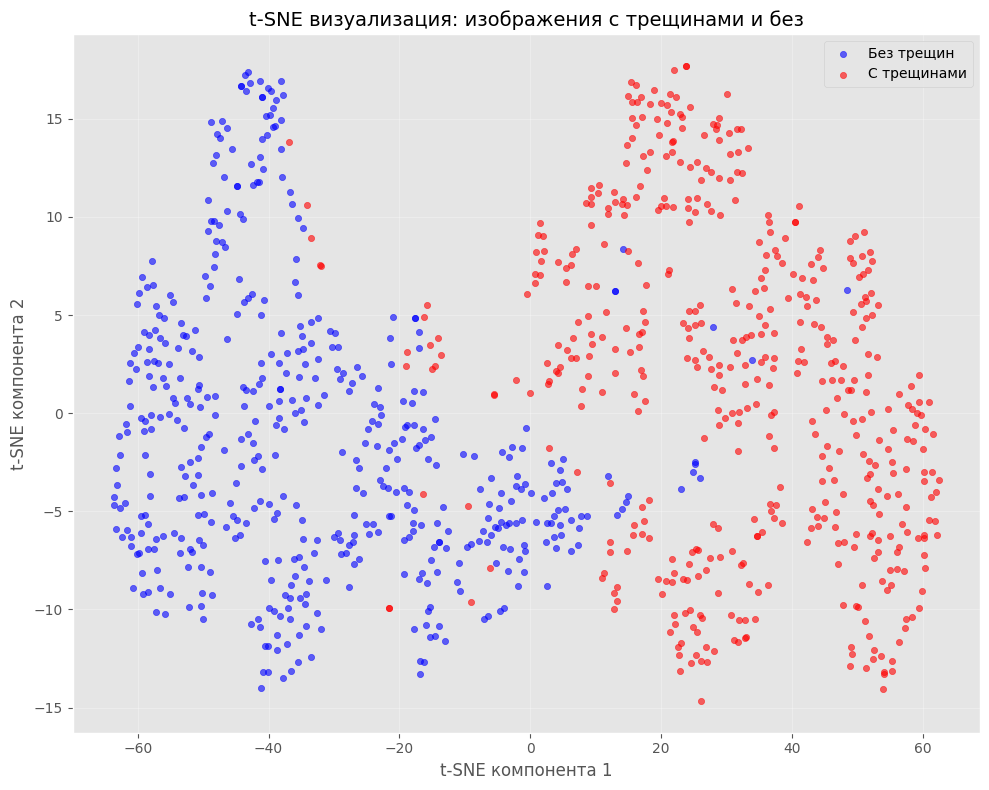

Силуэтный коэффициент (separability): 0.545
Интерпретация: >0.5 - хорошее разделение, <0.2 - слабое


In [17]:
# === ЭТАП 4: PCA И t-SNE ===

def apply_dimensionality_reduction(features, n_components_pca=10, perplexity=30):
    """
    Оптимизированная версия с учетом анализа объяснённой дисперсии.
    Рекомендуется использовать n_components_pca=10 для t-SNE.
    """
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE

    print(f"Исходная размерность признаков: {features.shape[1]}")
    print(f"Используем PCA с n_components = {n_components_pca}")

    # PCA с оптимальным числом компонент
    pca = PCA(n_components=n_components_pca, random_state=42)
    features_pca = pca.fit_transform(features)

    explained_variance = sum(pca.explained_variance_ratio_)
    print(f"   Сохранено дисперсии: {explained_variance:.3f} ({explained_variance*100:.1f}%)")
    print(f"   Размерность после PCA: {features_pca.shape[1]}")

    # t-SNE для визуализации
    tsne = TSNE(n_components=2,
                perplexity=perplexity,
                random_state=42,
                n_iter=1000,
                learning_rate='auto')

    features_tsne = tsne.fit_transform(features_pca)
    print(f"   Размерность после t-SNE: {features_tsne.shape[1]}")

    return features_pca, features_tsne, pca

# === ЭТАП 5: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ===

def visualize_results(features_tsne, labels, title="t-SNE визуализация признаков"):
    """
    Визуализирует результаты t-SNE с раскраской по классам.
    """
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 8))

    # Разделяем точки по классам
    mask_negative = (labels == 0)  # Без трещин
    mask_positive = (labels == 1)  # С трещинами

    plt.scatter(features_tsne[mask_negative, 0],
                features_tsne[mask_negative, 1],
                alpha=0.6, s=20, c='blue', label='Без трещин')

    plt.scatter(features_tsne[mask_positive, 0],
                features_tsne[mask_positive, 1],
                alpha=0.6, s=20, c='red', label='С трещинами')

    plt.title(title, fontsize=14)
    plt.xlabel('t-SNE компонента 1')
    plt.ylabel('t-SNE компонента 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Анализ разделимости
    from sklearn.metrics import silhouette_score
    if len(np.unique(labels)) > 1:
        score = silhouette_score(features_tsne, labels)
        print(f"Силуэтный коэффициент (separability): {score:.3f}")
        print("Интерпретация: >0.5 - хорошее разделение, <0.2 - слабое")

# Применяем PCA и t-SNE
print("\n" + "=" * 70)
print("ПРИМЕНЕНИЕ PCA И t-SNE")
print("=" * 70)

X_pca, X_tsne, pca_model = apply_dimensionality_reduction(X)

# Визуализируем результаты
print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 70)

visualize_results(X_tsne, y, title="t-SNE визуализация: изображения с трещинами и без")

ВЫЯВЛЕНИЕ ПОДКЛАССОВ: ИЕРАРХИЧЕСКАЯ АГГЛОМЕРАТИВНАЯ КЛАСТЕРИЗАЦИЯ

1. Подготовка данных для кластеризации...
Размерность данных для кластеризации: (1000, 50)
Используемый метод: AgglomerativeClustering (иерархическая агломеративная кластеризация)
Метод строит иерархию кластеров 'снизу вверх', последовательно объединяя наиболее близкие объекты.

2. Построение дендрограммы для определения оптимального числа кластеров...


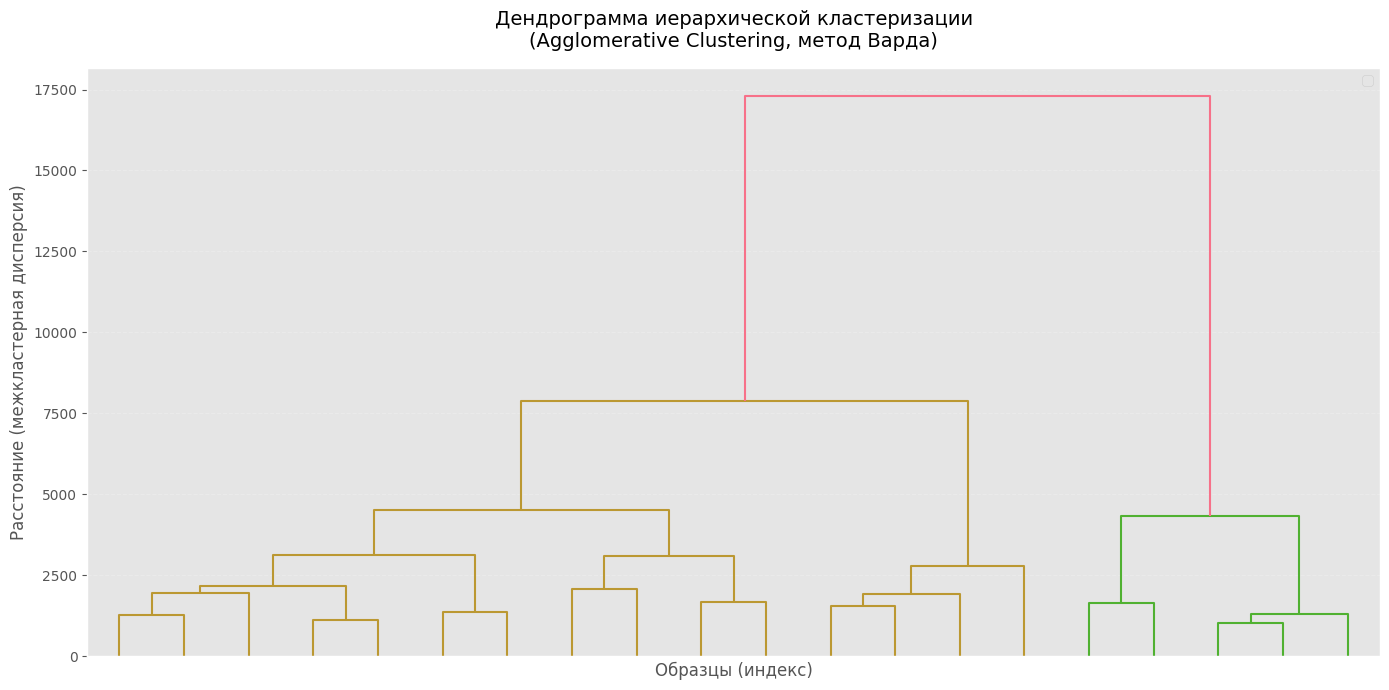

Анализ дендрограммы:
• Длинные вертикальные линии между горизонтальными указывают на 'естественные' разрывы между кластерами

3. Кластеризация для разных значениях k с оценкой качества...

--------------------------------------------------
Кластеризация с n_clusters = 2
--------------------------------------------------

Метрики качества кластеризации для k=2:
  • Силуэтный коэффициент: 0.567 (хорошее разделение)
  • Индекс Калински-Харабаса: 1560
Распределение изображений по кластерам:
  Кластер 0: 405 изображений | 396 с трещинами,   9 без |  97.8% трещин
  Кластер 1: 595 изображений | 104 с трещинами, 491 без |  17.5% трещин

--------------------------------------------------
Кластеризация с n_clusters = 3
--------------------------------------------------

Метрики качества кластеризации для k=3:
  • Силуэтный коэффициент: 0.486 (умеренное разделение)
  • Индекс Калински-Харабаса: 1395
Распределение изображений по кластерам:
  Кластер 0: 186 изображений | 185 с трещинами,   1 без | 

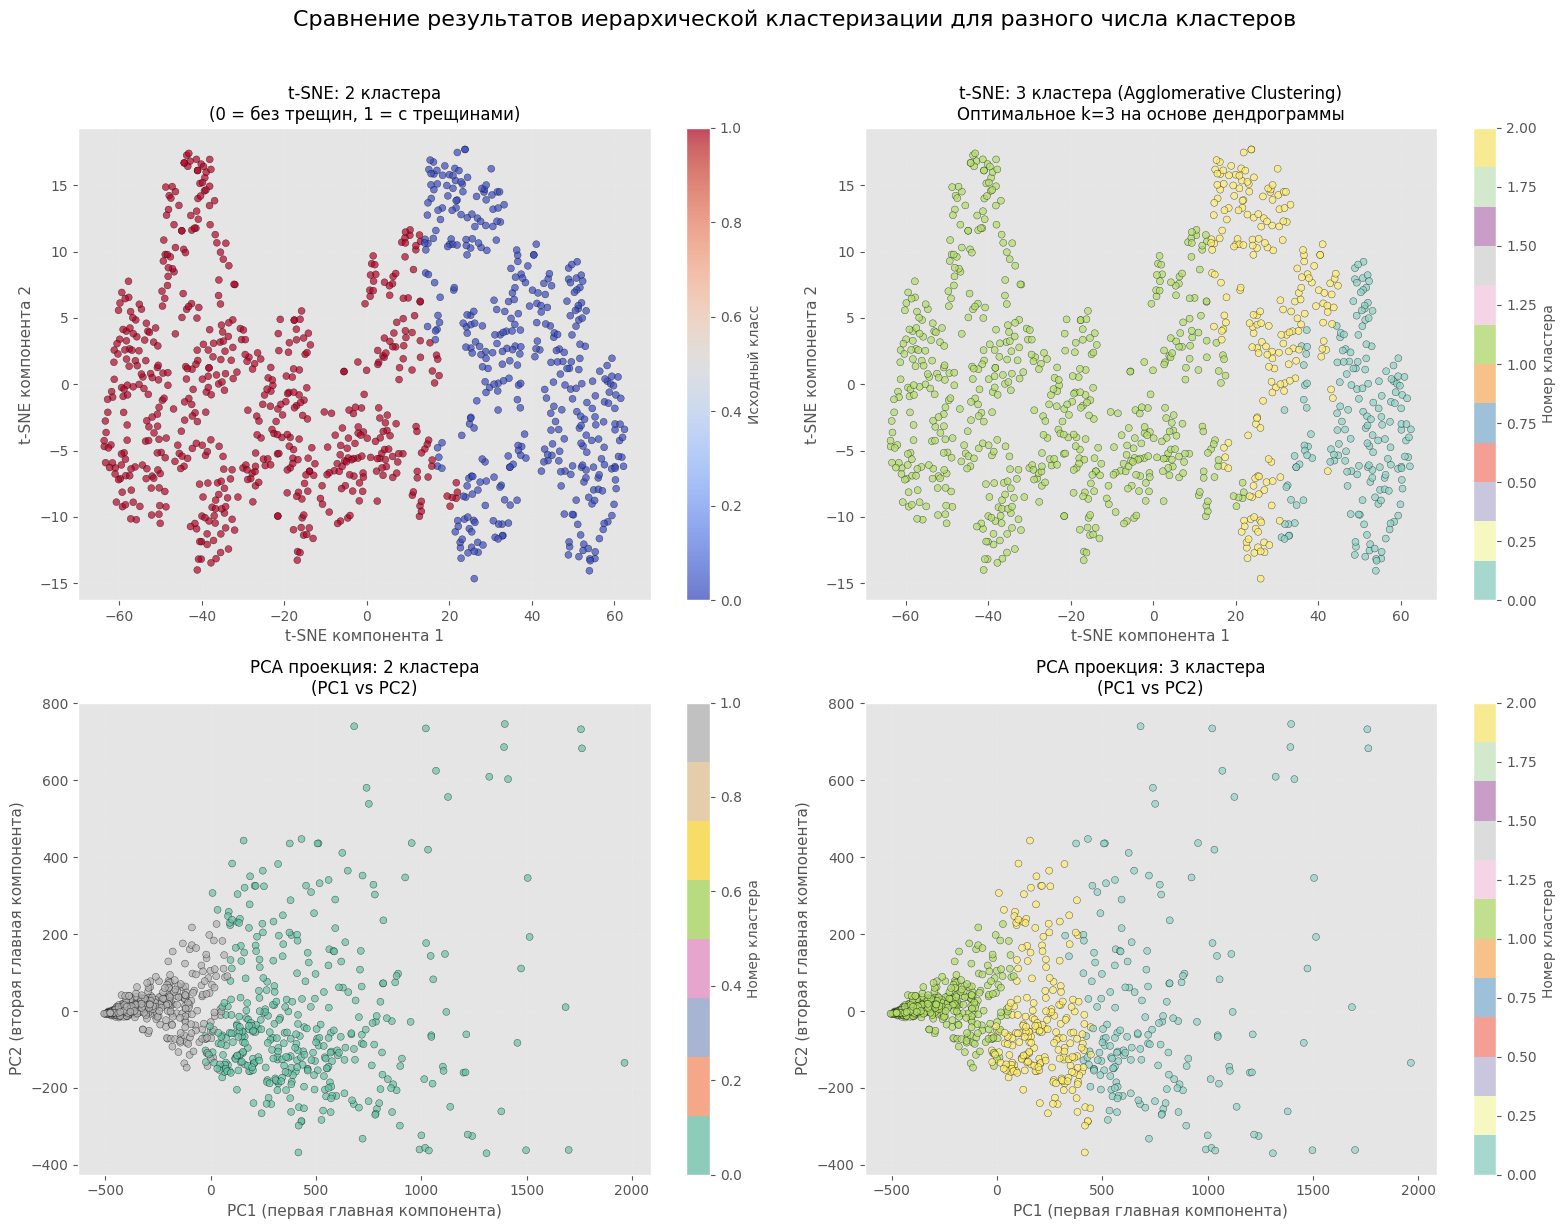


5. АНАЛИЗ КЛАСТЕРОВ ДЛЯ k=3

СТАТИСТИКА ПО КЛАСТЕРАМ (k=3):
----------------------------------------------------------------------------------------------------
         размер  %_трещин  PC1_сред  PC1_стд  PC2_сред
cluster                                               
0           186    99.462   766.510  317.973     8.267
1           595    17.479  -318.983  142.375     8.741
2           219    96.347   215.635  119.488   -30.770


In [18]:
# === ЭТАП 6: ВЫЯВЛЕНИЕ ПОДКЛАССОВ С ПОМОЩЬЮ АГГЛОМЕРАТИВНОЙ КЛАСТЕРИЗАЦИИ ===

print("=" * 70)
print("ВЫЯВЛЕНИЕ ПОДКЛАССОВ: ИЕРАРХИЧЕСКАЯ АГГЛОМЕРАТИВНАЯ КЛАСТЕРИЗАЦИЯ")
print("=" * 70)

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 6.1. Подготовка данных для кластеризации
print("\n1. Подготовка данных для кластеризации...")

# Используем PCA-признаки для кластеризации (сокращенные до 10 компонент)
X_for_clustering = X_pca  # PCA-признаки (10 компонент)

print(f"Размерность данных для кластеризации: {X_for_clustering.shape}")
print(f"Используемый метод: AgglomerativeClustering (иерархическая агломеративная кластеризация)")
print("Метод строит иерархию кластеров 'снизу вверх', последовательно объединяя наиболее близкие объекты.")

# 6.2. Построение дендрограммы для определения оптимального числа кластеров
print("\n2. Построение дендрограммы для определения оптимального числа кластеров...")

# Вычисляем матрицу связей методом Варда (минимизирует дисперсию внутри кластеров)
linked = linkage(X_for_clustering, method='ward', metric='euclidean')

# Строим дендрограмму
plt.figure(figsize=(14, 7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           truncate_mode='lastp',  # Показываем только последние p объединений
           p=20,  # Показываем 20 последних слияний
           no_labels=True,
           leaf_font_size=8)
plt.title('Дендрограмма иерархической кластеризации\n(Agglomerative Clustering, метод Варда)', fontsize=14, pad=15)
plt.xlabel('Образцы (индекс)', fontsize=12)
plt.ylabel('Расстояние (межкластерная дисперсия)', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

print("Анализ дендрограммы:")
print("• Длинные вертикальные линии между горизонтальными указывают на 'естественные' разрывы между кластерами")

# 6.3. Кластеризация для разных значений k с оценкой качества
print("\n3. Кластеризация для разных значениях k с оценкой качества...")

n_clusters_options = [2, 3]

# Словарь для хранения результатов
clustering_results = {}

for n_clusters in n_clusters_options:
    print(f"\n" + "-"*50)
    print(f"Кластеризация с n_clusters = {n_clusters}")
    print("-"*50)

    # Создаём и применяем модель Agglomerative Clustering
    clustering = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage='ward',  # Метод Варда минимизирует дисперсию внутри кластеров
        metric='euclidean'
    )

    cluster_labels = clustering.fit_predict(X_for_clustering)
    clustering_results[n_clusters] = cluster_labels

    # Оцениваем качество кластеризации
    from sklearn.metrics import silhouette_score, calinski_harabasz_score
    sil_score = silhouette_score(X_for_clustering, cluster_labels)
    ch_score = calinski_harabasz_score(X_for_clustering, cluster_labels)

    print(f"\nМетрики качества кластеризации для k={n_clusters}:")
    print(f"  • Силуэтный коэффициент: {sil_score:.3f} ({'хорошее' if sil_score > 0.5 else 'умеренное' if sil_score > 0.3 else 'слабое'} разделение)")
    print(f"  • Индекс Калински-Харабаса: {ch_score:.0f}")

    # Анализируем распределение по кластерам
    print(f"Распределение изображений по кластерам:")
    for i in range(n_clusters):
        cluster_mask = (cluster_labels == i)
        cluster_size = np.sum(cluster_mask)

        # Определяем состав кластера по исходным классам
        if np.sum(cluster_mask) > 0:
            class_in_cluster = y[cluster_mask]
            negative_count = np.sum(class_in_cluster == 0)
            positive_count = np.sum(class_in_cluster == 1)
            percent_cracks = positive_count / cluster_size * 100 if cluster_size > 0 else 0

            cluster_type = "ТРЕЩИНЫ" if percent_cracks > 80 else "БЕЗ ТРЕЩИН" if percent_cracks < 20 else "СМЕШАННЫЙ"

            print(f"  Кластер {i}: {cluster_size:3d} изображений | {positive_count:3d} с трещинами, {negative_count:3d} без | {percent_cracks:5.1f}% трещин")


# 6.4. Визуализация результатов для k=2 и k=3
print("\n" + "=" * 70)
print("4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ")
print("=" * 70)

# Создаем фигуру с двумя строками и двумя столбцами
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Сравнение результатов иерархической кластеризации для разного числа кластеров',
             fontsize=16, y=1.02)

# Верхняя строка: t-SNE проекции
k2_labels = clustering_results[2]
k3_labels = clustering_results[3]

# График 1: t-SNE с исходными классами (2 класса)
sc1 = axes[0, 0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                         c=k2_labels, cmap='coolwarm', alpha=0.7, s=25, edgecolor='k', linewidth=0.3)
axes[0, 0].set_title('t-SNE: 2 кластера\n(0 = без трещин, 1 = с трещинами)', fontsize=12)
axes[0, 0].set_xlabel('t-SNE компонента 1', fontsize=11)
axes[0, 0].set_ylabel('t-SNE компонента 2', fontsize=11)
axes[0, 0].grid(True, alpha=0.2, linestyle=':')
cbar1 = plt.colorbar(sc1, ax=axes[0, 0])
cbar1.set_label('Исходный класс', fontsize=10)

# График 2: t-SNE с 3 кластерами (Agglomerative Clustering)
sc2 = axes[0, 1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                         c=k3_labels, cmap='Set3', alpha=0.7, s=25, edgecolor='k', linewidth=0.3)
axes[0, 1].set_title('t-SNE: 3 кластера (Agglomerative Clustering)\nОптимальное k=3 на основе дендрограммы', fontsize=12)
axes[0, 1].set_xlabel('t-SNE компонента 1', fontsize=11)
axes[0, 1].set_ylabel('t-SNE компонента 2', fontsize=11)
axes[0, 1].grid(True, alpha=0.2, linestyle=':')
cbar2 = plt.colorbar(sc2, ax=axes[0, 1])
cbar2.set_label('Номер кластера', fontsize=10)

# Нижняя строка: PCA проекции
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]

# График 3: PCA проекция с 2 кластерами
sc3 = axes[1, 0].scatter(pc1, pc2,
                         c=k2_labels, cmap='Set2', alpha=0.7, s=25, edgecolor='k', linewidth=0.3)
axes[1, 0].set_title('PCA проекция: 2 кластера\n(PC1 vs PC2)', fontsize=12)
axes[1, 0].set_xlabel('PC1 (первая главная компонента)', fontsize=11)
axes[1, 0].set_ylabel('PC2 (вторая главная компонента)', fontsize=11)
axes[1, 0].grid(True, alpha=0.2, linestyle=':')
cbar3 = plt.colorbar(sc3, ax=axes[1, 0])
cbar3.set_label('Номер кластера', fontsize=10)

# График 4: PCA проекция с 3 кластерами
sc4 = axes[1, 1].scatter(pc1, pc2,
                         c=k3_labels, cmap='Set3', alpha=0.7, s=25, edgecolor='k', linewidth=0.3)
axes[1, 1].set_title('PCA проекция: 3 кластера\n(PC1 vs PC2)', fontsize=12)
axes[1, 1].set_xlabel('PC1 (первая главная компонента)', fontsize=11)
axes[1, 1].set_ylabel('PC2 (вторая главная компонента)', fontsize=11)
axes[1, 1].grid(True, alpha=0.2, linestyle=':')
cbar4 = plt.colorbar(sc4, ax=axes[1, 1])
cbar4.set_label('Номер кластера', fontsize=10)

plt.tight_layout()
plt.show()

# 6.5. Детальный анализ кластеров для k=3 (основной вариант)
print("\n" + "=" * 70)
print("5. АНАЛИЗ КЛАСТЕРОВ ДЛЯ k=3")
print("=" * 70)

optimal_n_clusters = 3
final_cluster_labels = clustering_results[optimal_n_clusters]

# Создаём DataFrame для анализа
analysis_df = pd.DataFrame({
    'cluster': final_cluster_labels,
    'true_class': y,
    'pc1': X_pca[:, 0],
    'pc2': X_pca[:, 1],
    'tsne1': X_tsne[:, 0],
    'tsne2': X_tsne[:, 1]
})

# Группируем по кластерам и анализируем
cluster_summary = analysis_df.groupby('cluster').agg({
    'true_class': ['count', lambda x: np.sum(x == 1) / len(x) * 100],
    'pc1': ['mean', 'std', 'min', 'max'],
    'pc2': ['mean', 'std'],
    'tsne1': ['mean', 'std'],
    'tsne2': ['mean', 'std']
}).round(3)

# Переименовываем столбцы для удобства
new_columns = ['размер', '%_трещин',
               'PC1_сред', 'PC1_стд', 'PC1_min', 'PC1_max',
               'PC2_сред', 'PC2_стд',
               'tSNE1_сред', 'tSNE1_стд',
               'tSNE2_сред', 'tSNE2_стд']
cluster_summary.columns = new_columns

print("\nСТАТИСТИКА ПО КЛАСТЕРАМ (k=3):")
print("-" * 100)
print(cluster_summary[['размер', '%_трещин', 'PC1_сред', 'PC1_стд', 'PC2_сред']])
